In [1]:
# Due to the size of models trained here, the notebook had to be run on google colab
# Data must be mounted to google colab to run this notebook

# Mount drive to access datasets
from google.colab import drive
drive.mount('/content/drive')

# Data used here is augmented data produced using the notebook:  2.2-suzy-data-augmentation.ipynb
# Data is stored in the following directory in google drive:
# Colab Notebooks/anomalies_multi_class/split_val_test_before_augmentation/transistor
# With a subdirectory each for the train, validation and holdout (test) sets


Mounted at /content/drive


# Multi-class transistor anomaly classification with pre-split then augmented anomaly images

In [2]:
# Library imports

from pathlib import Path
import os
import cv2
import numpy as np
import pandas as pd

# Imports for visualizations
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Imports for ML
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.metrics import classification_report_imbalanced


In [3]:
# Imports for CNNs

# Imports for building the model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import LeakyReLU
# Imports for model training
from tensorflow.keras.callbacks import EarlyStopping

# Imports for image transformations
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import Resizing
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomBrightness
from tensorflow.keras.layers import RandomContrast
from tensorflow.keras.layers import RandomTranslation
from tensorflow.keras.layers import GlobalAveragePooling2D

# Importing the image_dataset_from_directory utility from Keras
from keras.utils import image_dataset_from_directory

# Importing loss function
from tensorflow.keras.losses import CategoricalCrossentropy

# Imports for using a pre-trained model mobilenet
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.mobilenet import preprocess_input, decode_predictions

import tensorflow as tf


In [4]:
# Functions

def plot_training(model_history):
    train_loss = model_history.history["loss"]
    val_loss = model_history.history["val_loss"]

    train_acc = model_history.history["accuracy"]
    val_acc = model_history.history["val_accuracy"]

    plt.figure(figsize=(20, 8))

    # Plot the MSE loss
    plt.subplot(121)
    plt.plot(train_loss)
    plt.plot(val_loss)
    plt.title('Model Loss per Epoch (MSE)')
    plt.ylabel('Loss (MSE)')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'], loc='best')

    # Plot the Mean Absolute Error (MAE)
    plt.subplot(122)
    plt.plot(train_acc)
    plt.plot(val_acc)
    plt.title('Accuracy per Epoch')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'], loc='best')

    plt.show()


def get_predictions_and_labels(model, dataset):
    true_labels = []
    pred_labels = []

    for images, labels in dataset:

        preds = model.predict(images, verbose=0)  # Get the model's predictions
        pred_labels.extend(np.argmax(preds, axis=-1))  # Get the predicted labels (argmax)

        true_labels.extend(labels.numpy())  # Get the true labels

    return np.array(true_labels), np.array(pred_labels)


def plot_cm(y_true, y_pred):
    plt.figure(figsize=(10, 10))  # Create a large figure for the confusion matrix
    cnf_matrix = confusion_matrix(y_true, y_pred, normalize='true')  # Compute the normalized confusion matrix
    sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt=".2f")  # Plot the confusion matrix as a heatmap
    plt.show()


def cm_bin(y_true, y_pred):
    cnf_matrix = pd.crosstab(y_true, y_pred, rownames=['True Class'], colnames=['Predicted Class'])
    display(cnf_matrix)

def deprocess_vgg16(x):
    # Reverses the preprocessing done by tf.keras.applications.vgg16.preprocess_input
    # x is a BGR array with mean subtracted
    x = x.copy()
    mean = [103.939, 116.779, 123.68]  # BGR mean values

    x[..., 0] += mean[0]
    x[..., 1] += mean[1]
    x[..., 2] += mean[2]

    # Convert BGR to RGB
    x = x[..., ::-1]

    x = np.clip(x, 0, 255).astype('uint8')
    return x

def grad_cam(image, model, layer_name):
    # Retrieve the convolutional layer
    layer = model.get_layer(layer_name)

    # Create a model that generates the outputs of the convolutional layer and the predictions
    grad_model = Model(inputs=model.input, outputs=[layer.output, model.output])

    # Add a batch dimension. Ensure the image passed to grad_model is float32 and preprocessed.
    # The 'image' input to this function (grad_cam) is already expected to be preprocessed float32.
    image_for_model = tf.expand_dims(image, axis=0)

    # Compute the gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image_for_model) # Use image_for_model here
        predicted_class = tf.argmax(predictions[0])  # Predicted class
        # Ensure 'loss' is a scalar for tape.gradient
        loss = predictions[:, predicted_class]

    # Gradients of the scores with respect to the outputs of the convolutional layer
    grads = tape.gradient(loss, conv_outputs)

    # Weighted average of the gradients for each channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the activations by the calculated gradients
    conv_outputs = conv_outputs[0]  # Remove the batch dimension
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)

    # Normalize the heatmap
    heatmap = tf.maximum(heatmap, 0)  # Focus only on positive values
    # Handle potential division by zero if heatmap is all zeros
    if tf.math.reduce_max(heatmap) > 0:
        heatmap /= tf.math.reduce_max(heatmap)  # Normalize between 0 and 1
    else:
        heatmap = tf.zeros_like(heatmap) # If all zeros, keep it as zeros
    heatmap = heatmap.numpy()  # Convert to numpy array for visualization

    # Resize the heatmap to match the original image size
    # Use image.shape[0] and image.shape[1] for height and width of the single image
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], (image.shape[0], image.shape[1])).numpy()
    heatmap_resized = np.squeeze(heatmap_resized, axis=-1)  # Remove the singleton dimension at the end of the heatmap_resized array

    return heatmap_resized, predicted_class.numpy()

def show_grad_cam_cnn(images, model, class_names):
    number_of_images = images.shape[0]
    # Get convolutional layers from the VGG16 base model, if it's the first layer of the model
    # Or directly from the VGG16 application if the model is built differently

    # Access the VGG16 model which is the first layer of `model`
    if isinstance(model.layers[0], tf.keras.Model) and model.layers[0].name == 'vgg16':
        base_vgg_model = model.layers[0]
        conv_layers = [layer.name for layer in base_vgg_model.layers if isinstance(layer, tf.keras.layers.Conv2D)]
    else:
        # Fallback if VGG16 is not the first layer or not named 'vgg16'
        # This might need adjustment based on how the VGG16 model is truly integrated
        conv_layers = [layer.name for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)]

    # Use only the last convolutional block's last layer for Grad-CAM for clarity
    if conv_layers: # Check if list is not empty
        # A typical VGG16 last conv layer is in block5_conv3 or similar
        target_conv_layer = [l for l in conv_layers if 'block5_conv3' in l or 'conv3' in l][-1] # Get last conv layer of the last block
    else:
        print("No convolutional layers found in the model.")
        return

    plt.figure(figsize=(4 * number_of_images, 5))

    for i in range(number_of_images):
        original_image_display = deprocess_vgg16(images[i])

        # Get the heatmap and predicted class from grad_cam function
        heatmap, predicted_class_idx = grad_cam(images[i], model, target_conv_layer)
        predicted_class_name = class_names[predicted_class_idx]

        # Convert heatmap to RGB
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

        # Superimpose the heatmap on the original image
        superimposed_img = heatmap * 0.4 + original_image_display
        superimposed_img = np.clip(superimposed_img, 0, 255).astype('uint8')

        # Plotting
        plt.subplot(1, number_of_images, i + 1)
        plt.imshow(superimposed_img)
        plt.title(f'Predicted: {predicted_class_name}\nLayer: {target_conv_layer}')
        plt.axis("off")

    plt.tight_layout()
    plt.show()


In [5]:
# Callbacks for model training

early_stopping = EarlyStopping(
                                patience=5,
                                min_delta=0.01,
                                mode='min',
                                monitor='val_loss')


## Transfer learning with Mobilenet for multi-class anomaly classification

In [6]:
# Datasets preparation (pre-split)

train_dir = '/content/drive/My Drive/Colab Notebooks/anomalies_multi_class/split_val_test_before_augmentation/transistor/train'
val_dir = '/content/drive/My Drive/Colab Notebooks/anomalies_multi_class/split_val_test_before_augmentation/transistor/validation'
holdout_dir = '/content/drive/My Drive/Colab Notebooks/anomalies_multi_class/split_val_test_before_augmentation/transistor/holdout'

train_ds = image_dataset_from_directory(
    train_dir,
    seed=42,
    batch_size=16,
    labels='inferred',
    label_mode='int',
    image_size=(224, 224)  # Resize images for VGG16
)

val_ds = image_dataset_from_directory(
    val_dir,
    seed=42,
    batch_size=16,
    labels='inferred',
    label_mode='int',
    image_size=(224, 224)  # Resize images for VGG16
)

test_ds = image_dataset_from_directory(
    holdout_dir,
    seed=42,
    batch_size=16,
    labels='inferred',
    label_mode='int',
    image_size=(224, 224)  # Resize images for VGG16
)

Found 975 files belonging to 5 classes.
Found 308 files belonging to 5 classes.
Found 103 files belonging to 5 classes.


In [7]:
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y))


Mobilenet model with pretrained layers accessible

In [51]:
import keras

inputs = Input(shape=(224, 224, 3))

# Instantiate the MobileNetV2 base model
# It's crucial to pass input_tensor=inputs so its layers are integrated into the new model's graph
base_model = tf.keras.applications.MobileNetV2(include_top=False, weights='imagenet', input_tensor=inputs)

# Freeze the base model layers if you don't want to retrain them
# It's common to freeze them initially for feature extraction
# base_model.trainable = False

# Get the output from the base model
x = base_model.output

# Add new layers on top of the model
x = tf.keras.layers.GlobalAveragePooling2D()(x)
# x = tf.keras.layers.Dropout(DROPOUT)(x) # optional for your own experiments
x = tf.keras.layers.Dense(512, activation='relu')(x)
predictions = tf.keras.layers.Dense(5, activation='softmax', name="output")(x)

model_m = tf.keras.models.Model(inputs=inputs, outputs=predictions, name="ft_net")

model_m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/tmp/ipython-input-3935288940.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(include_top=False, weights='imagenet', input_tensor=inputs)


In [52]:
model_m.summary()


Model: "ft_net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_10[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,916,421 (11.13 MB)

 Trainable params: 2,882,309 (11.00 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [53]:
# Freezing parameters of mobilenet layers

# Make the entire MobileNetV2 base model trainable to allow Grad-CAM to compute gradients.
# The base_model is model_m.layers[1]
if hasattr(model_m.layers[1], 'trainable'): # Check if the layer has a trainable attribute
    model_m.layers[1].trainable = True

# You can selectively freeze/unfreeze layers within base_model if needed,
# for example:
# for layer in model_m.layers[1].layers: # Iterate through layers of MobileNetV2
#    if 'block_16_project' in layer.name: # Example: Only make block_16_project and later trainable
#        layer.trainable = True
#    else:
#        layer.trainable = False


In [54]:
model_m.summary()


Model: "ft_net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_10[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,916,421 (11.13 MB)

 Trainable params: 658,437 (2.51 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [55]:
model_history = model_m.fit(train_ds,
                          validation_data=val_ds,
                          epochs=30,
                          callbacks=[early_stopping]
                         )


Epoch 1/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 62s 845ms/step - accuracy: 0.5900 - loss: 1.2002 - val_accuracy: 0.7110 - val_loss: 0.6621
Epoch 2/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 34s 553ms/step - accuracy: 0.9629 - loss: 0.1459 - val_accuracy: 0.8214 - val_loss: 0.4117
Epoch 3/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 36s 590ms/step - accuracy: 0.9780 - loss: 0.0622 - val_accuracy: 0.8312 - val_loss: 0.4116
Epoch 4/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 34s 565ms/step - accuracy: 0.9949 - loss: 0.0261 - val_accuracy: 0.8214 - val_loss: 0.4459
Epoch 5/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 44s 618ms/step - accuracy: 1.0000 - loss: 0.0142 - val_accuracy: 0.8409 - val_loss: 0.4323
Epoch 6/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 34s 567ms/step - accuracy: 0.9994 - loss: 0.0147 - val_accuracy: 0.8312 - val_loss: 0.4665
Epoch 7/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 36s 585ms/step - accuracy: 0.9996 - loss: 0.0105 - val_accuracy: 0.8149 - val_loss: 0.5006


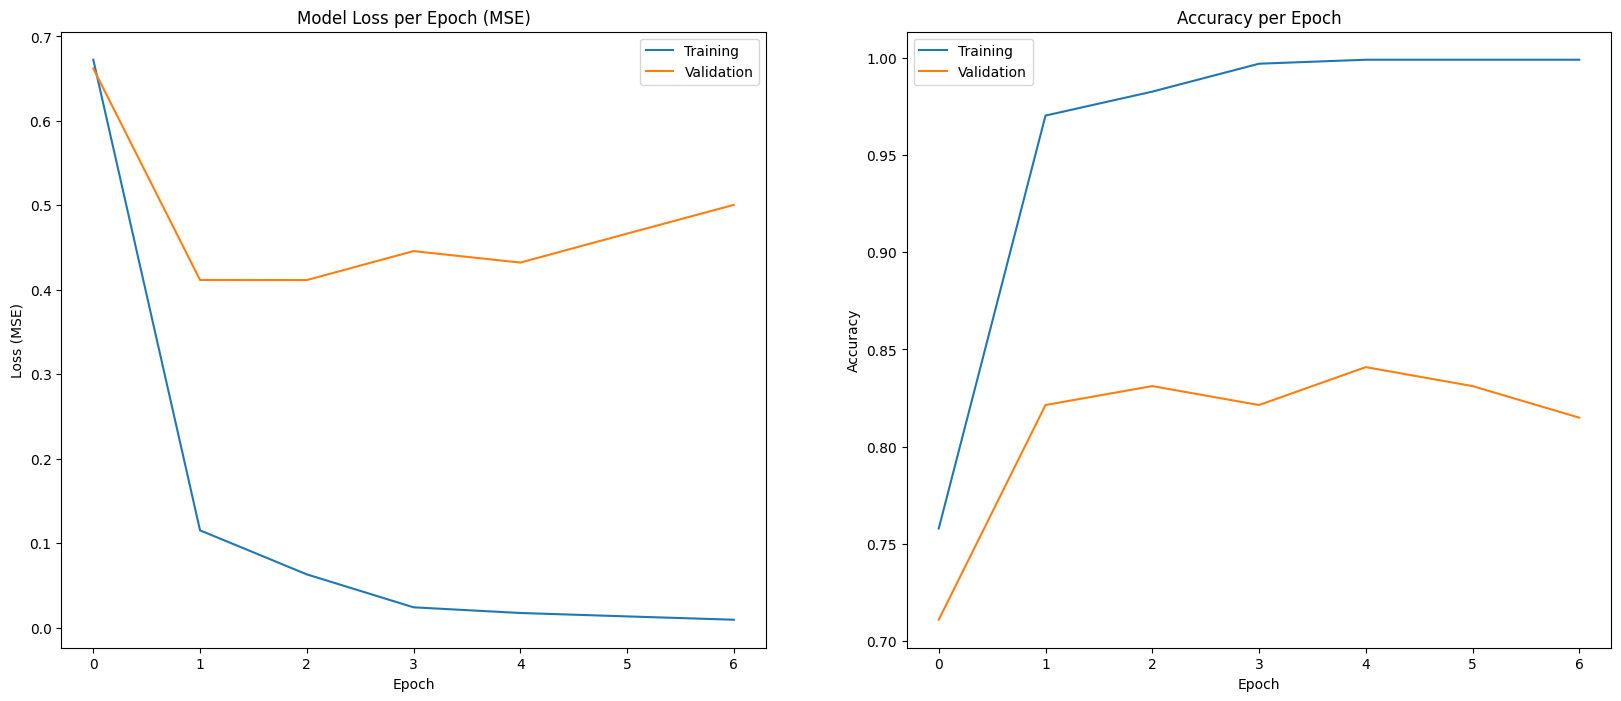

In [56]:
plot_training(model_history)


In [57]:
y_true, y_pred = get_predictions_and_labels(model_m, test_ds)  # Get true labels and predictions from the test dataset

# Display the classification report
print(classification_report(y_true, y_pred))  # Print the classification report (precision, recall, F1-score)


              precision    recall  f1-score   support

           0       0.76      0.76      0.76        21
           1       0.76      0.90      0.83        21
           2       1.00      1.00      1.00        21
           3       0.95      1.00      0.98        20
           4       0.93      0.70      0.80        20

    accuracy                           0.87       103
   macro avg       0.88      0.87      0.87       103
weighted avg       0.88      0.87      0.87       103



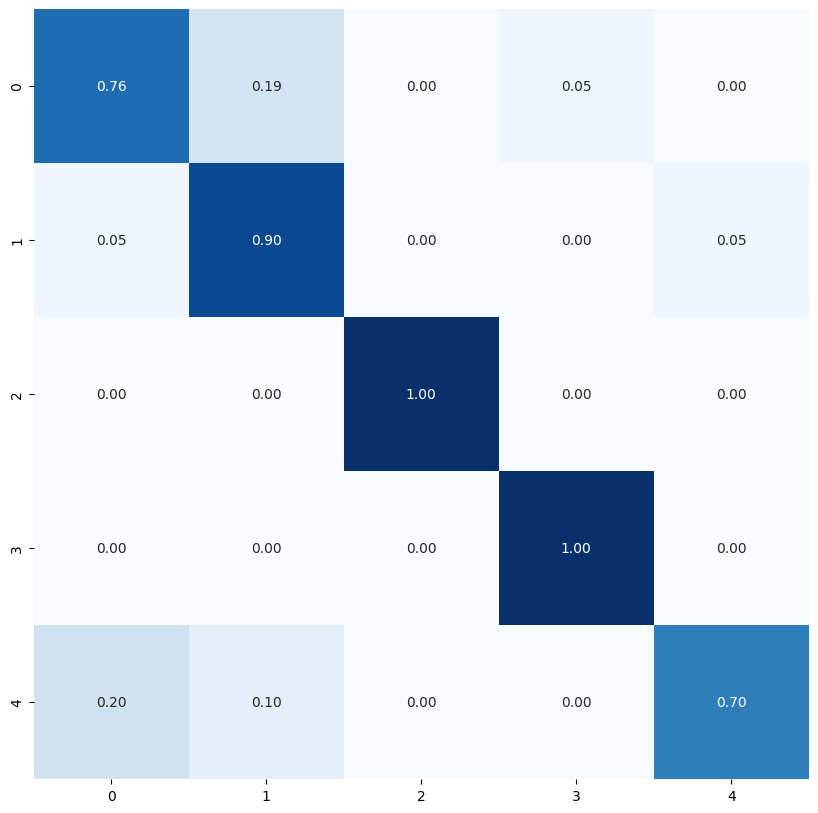

In [58]:
# Display the confusion matrix

plot_cm(y_true, y_pred)


In [59]:
print('Class names:')
print(sorted(os.listdir(train_dir)))


Class names:
['bent_lead', 'cut_lead', 'damaged_case', 'good', 'misplaced']


In [64]:
model_m.save('/content/drive/My Drive/Colab Notebooks/cnn_mobilenet.keras')
model_m.save_weights('/content/drive/My Drive/Colab Notebooks/cnn_mobilenet.weights.h5')


In [ ]:
#import keras

#model_m = keras.saving.load_model('/content/drive/My Drive/Colab Notebooks/cnn_mobilenet.keras')

In [60]:
# Take images from holdout set

class_names = sorted(os.listdir(holdout_dir))

# Get a single batch from the test dataset.
# The images in test_ds are already preprocessed by VGG16's preprocess_input
# and are of float32 dtype.
images_batch, labels_batch = next(iter(test_ds))

# Select the first 4 images and their corresponding labels from the batch.
# images will now be float32, as expected by the model
images = images_batch.numpy()[:4]
labels = labels_batch.numpy()[:4]

--- Debugging model.layers ---
Layer 0: Name=input_layer_10, Type=<class 'keras.src.layers.core.input_layer.InputLayer'>
Layer 1: Name=Conv1, Type=<class 'keras.src.layers.convolutional.conv2d.Conv2D'>
Layer 2: Name=bn_Conv1, Type=<class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'>
Layer 3: Name=Conv1_relu, Type=<class 'keras.src.layers.activations.relu.ReLU'>
Layer 4: Name=expanded_conv_depthwise, Type=<class 'keras.src.layers.convolutional.depthwise_conv2d.DepthwiseConv2D'>
Layer 5: Name=expanded_conv_depthwise_BN, Type=<class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'>
Layer 6: Name=expanded_conv_depthwise_relu, Type=<class 'keras.src.layers.activations.relu.ReLU'>
Layer 7: Name=expanded_conv_project, Type=<class 'keras.src.layers.convolutional.conv2d.Conv2D'>
Layer 8: Name=expanded_conv_project_BN, Type=<class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'>
Layer 9: Name=block_1_expand, Type=<class 'k

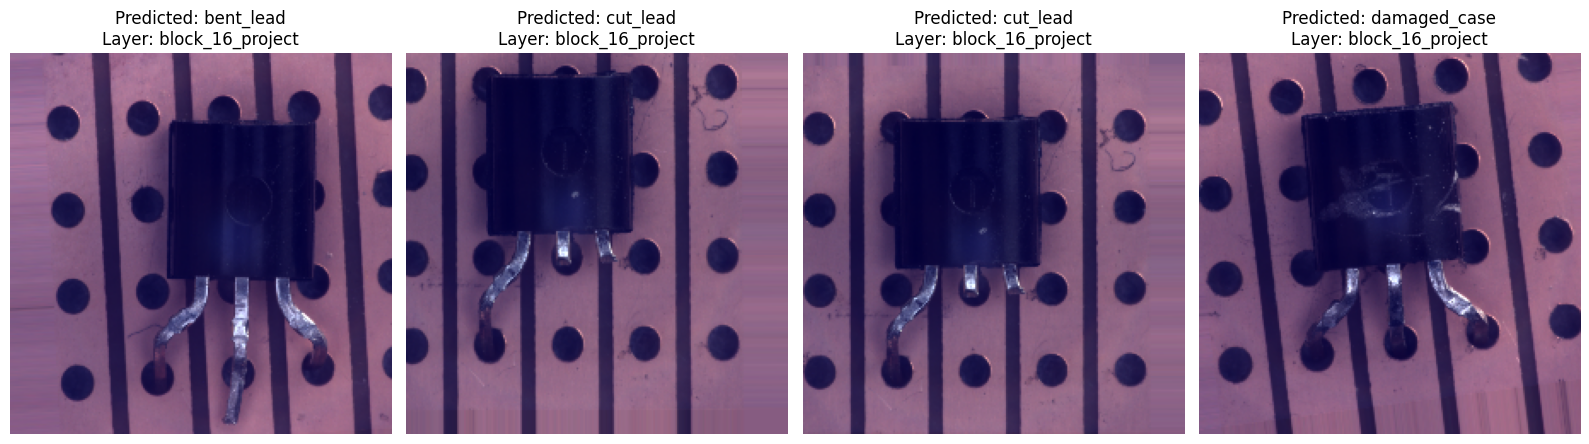

In [66]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model # Import Model here

def deprocess_xception(x):
    # Reverses the preprocessing done by tf.keras.applications.xception.preprocess_input
    # x is scaled to [-1, 1]
    x = x.copy()
    x = x * 127.5 + 127.5 # Rescale from [-1, 1] to [0, 255]
    x = np.clip(x, 0, 255).astype('uint8')
    return x

def grad_cam(image, model, target_layer):
    image_for_model = tf.expand_dims(image, axis=0)

    # 1. Create a model that extracts features from the target layer
    feature_extractor = Model(inputs=model.input, outputs=target_layer.output)

    with tf.GradientTape() as tape:
        # Compute the activations of the target layer
        # Make sure these activations are watched by the tape for gradient calculation
        conv_outputs = feature_extractor(image_for_model)
        tape.watch(conv_outputs)

        # Compute the predictions of the full model using the same input
        predictions = model(image_for_model)
        predicted_class_idx = tf.argmax(predictions[0])
        # Get the score for the predicted class
        class_channel_score = predictions[0, predicted_class_idx]

    # 2. Compute gradients of the predicted class score with respect to the conv_outputs
    grads = tape.gradient(class_channel_score, conv_outputs)

    # Handle case where gradients might be None (e.g., if target_layer is not connected to loss)
    if grads is None:
        tf.print("Warning: Gradients are None for target layer.", target_layer.name)
        # If gradients are None, return a heatmap of zeros, ensuring correct size
        # Use the shape of the resized output if available, or original image size
        return np.zeros((image.shape[0], image.shape[1])), predicted_class_idx.numpy()

    # Apply global average pooling to the gradients to get weights for each filter
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the activations by the calculated gradients
    conv_outputs = conv_outputs[0] # Remove batch dimension
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)

    # Normalize the heatmap
    heatmap = tf.maximum(heatmap, 0)
    max_heatmap = tf.math.reduce_max(heatmap)
    if max_heatmap == 0: # Avoid division by zero
        heatmap = tf.zeros_like(heatmap)
    else:
        heatmap /= max_heatmap
    heatmap = heatmap.numpy()

    # Resize the heatmap to match the original image size
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], (image.shape[0], image.shape[1])).numpy()
    heatmap_resized = np.squeeze(heatmap_resized, axis=-1)

    return heatmap_resized, predicted_class_idx.numpy()

def show_grad_cam_cnn(images, model, class_names):
    number_of_images = images.shape[0]

    target_conv_layer_obj = None
    target_conv_layer_name = ""

    tf.print("--- Debugging model.layers ---")
    for i, layer in enumerate(model.layers):
        tf.print(f"Layer {i}: Name={layer.name}, Type={type(layer)}")
    tf.print("------------------------------")

    # Given the flat structure observed, directly search for 'block_16_project'
    # which is a common and effective layer for Grad-CAM in MobileNetV2.
    try:
        target_conv_layer_obj = model.get_layer('block_16_project')
        target_conv_layer_name = 'block_16_project'
        tf.print(f"Selected target convolutional layer for Grad-CAM: {target_conv_layer_name}")
    except ValueError:
        tf.print("Could not find 'block_16_project' layer. Falling back to generic last conv layer search.")
        # Fallback to generic last conv layer if 'block_16_project' is not found
        for layer in reversed(model.layers):
            if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.DepthwiseConv2D)):
                target_conv_layer_obj = layer
                target_conv_layer_name = layer.name
                break

    if not target_conv_layer_obj:
        tf.print("No suitable convolutional layer found in the model for Grad-CAM.")
        return
    else:
        tf.print(f"Final selected target convolutional layer for Grad-CAM: {target_conv_layer_name}")

    plt.figure(figsize=(4 * number_of_images, 5))

    for i in range(number_of_images):
        original_image_display = deprocess_xception(images[i])

        # Pass the actual layer object to grad_cam
        heatmap, predicted_class_idx = grad_cam(images[i], model, target_conv_layer_obj)
        predicted_class_name = class_names[predicted_class_idx]

        # Convert heatmap to RGB
        # Ensure heatmap is correctly resized before color mapping
        if heatmap.shape != (original_image_display.shape[0], original_image_display.shape[1]):
             heatmap = tf.image.resize(heatmap[..., np.newaxis], (original_image_display.shape[0], original_image_display.shape[1])).numpy()
             heatmap = np.squeeze(heatmap, axis=-1)

        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

        # Superimpose the heatmap on the original image
        superimposed_img = heatmap * 0.4 + original_image_display
        superimposed_img = np.clip(superimposed_img, 0, 255).astype('uint8')

        # Plotting
        plt.subplot(1, number_of_images, i + 1)
        plt.imshow(superimposed_img)
        plt.title(f'Predicted: {predicted_class_name}\nLayer: {target_conv_layer_name}')
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Call the modified function
show_grad_cam_cnn(images, model_m, class_names)

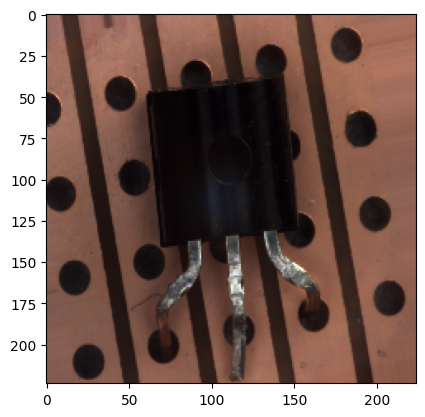

In [ ]:
plt.imshow(deprocess_xception(images[1]))